In [2]:
import pandas as pd
fba_df = pd.read_csv("fba_results.csv")
graph_df = pd.read_csv("graph_data_with_complexity.csv")

In [6]:
full_df = pd.merge(graph_df, fba_df, on='sample')
full_df = full_df.drop(columns=['status', 'condition_y'])

In [9]:
full_df

,sample,nodes,edges,avg_degree,global_clustering,avg_local_clustering,largest_connected_component,condition_x,diffusion_efficiency,modularity,assortativity,hierarchical_complexity,objective_value,total_abs_flux,active_reactions
0,TCGA_Tumor_A3A3,6496,64794,19.95,0.2261,0.6576,6482,Tumor,0.3447,0.712022,-0.132966,0.051354,124.859749,151577.453199,849
1,TCGA_Tumor_A3RK,6518,65317,20.04,0.2231,0.6584,6504,Tumor,0.3451,0.711624,-0.133225,0.055589,124.868148,158244.609113,945
2,TCGA_Tumor_A3KG,6480,64995,20.06,0.2257,0.6605,6466,Tumor,0.3450,0.708071,-0.133176,0.051049,124.868148,107372.483261,1002
3,TCGA_Tumor_AAU7,6578,65735,19.99,0.2210,0.6588,6559,Tumor,0.3440,0.712486,-0.133236,0.052163,124.867964,129567.000109,1295
4,TCGA_Tumor_A9VH,6535,65276,19.98,0.2228,0.6580,6516,Tumor,0.3438,0.712658,-0.133594,0.050500,124.868148,165189.256758,1216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,TCGA_Tumor_A5MZ,6532,65397,20.02,0.2221,0.6593,6513,Tumor,0.3443,0.712784,-0.133562,0.051237,124.868148,131739.702932,651
419,TCGA_Tumor_AACD,6467,64771,20.03,0.2286,0.6581,6450,Tumor,0.3438,0.709579,-0.133297,0.046075,124.868148,153346.125009,785
420,TCGA_Healthy_A1EG,6462,64684,20.02,0.2284,0.6568,6446,Healthy,0.3440,0.720046,-0.133286,0.051725,124.868148,161802.762754,1026
421,TCGA_Tumor_A73D,6426,64661,20.12,0.2277,0.6605,6407,Tumor,0.3448,0.709090,-0.134257,0.047778,124.868148,133986.302901,1005


## Mann-Whitney U to get P-values 

In [46]:
# Calculating P values for tumor and healthy
from scipy.stats import mannwhitneyu

# List of graph-related metrics to test
metrics = [
    'avg_degree',
    'global_clustering',
    'avg_local_clustering',
    'diffusion_efficiency',
    'modularity',
    'assortativity',
    'hierarchical_complexity',
    'objective_value',
    #'total_abs_flux',
    #'active_reactions'
]

# Split data by condition
tumor_df = full_df[full_df['condition_x'] == 'Tumor']
healthy_df = full_df[full_df['condition_x'] == 'Healthy']

# Storing p-values
p_values = {}

for metric in metrics:
    tumor_vals = tumor_df[metric]
    healthy_vals = healthy_df[metric]
    stat, p = mannwhitneyu(tumor_vals, healthy_vals, alternative='two-sided')
    p_values[metric] = p

In [48]:
# View results
import pandas as pd
pval_df = pd.DataFrame.from_dict(p_values, orient='index', columns=['p_value'])
pval_df = pval_df.sort_values(by='p_value')
pval_df

,p_value
avg_local_clustering,6.180001e-10
avg_degree,1.283101e-07
assortativity,7.935804e-04
diffusion_efficiency,3.144370e-03
modularity,1.665857e-02
global_clustering,8.934138e-02
hierarchical_complexity,2.003557e-01
objective_value,7.008725e-01


## Calculating meadians 

In [51]:
# Dictionary to store medians
median_tumor = tumor_df[metrics].median()
median_healthy = healthy_df[metrics].median()

# Combine into a DataFrame for comparison
median_df = pd.DataFrame({
    'median_tumor': median_tumor,
    'median_healthy': median_healthy
})

median_df

,median_tumor,median_healthy
avg_degree,20.040000,20.005000
global_clustering,0.225500,0.226850
avg_local_clustering,0.659800,0.657850
diffusion_efficiency,0.344700,0.344400
modularity,0.711919,0.713186
assortativity,-0.133477,-0.133704
hierarchical_complexity,0.050613,0.050790
objective_value,124.868148,124.868148


## Computing effect sizes 

In [54]:
# Compute effect size
median_df['effect_size'] = median_df['median_tumor'] - median_df['median_healthy']

# Combine p-values for easier plotting 
median_df['p_value'] = pval_df['p_value']

# Sort by effect size (absolute) for readability
median_df_sorted = median_df.reindex(median_df['effect_size'].abs().sort_values(ascending=False).index)

median_df_sorted

,median_tumor,median_healthy,effect_size,p_value
avg_degree,20.040000,20.005000,3.500000e-02,1.283101e-07
avg_local_clustering,0.659800,0.657850,1.950000e-03,6.180001e-10
global_clustering,0.225500,0.226850,-1.350000e-03,8.934138e-02
modularity,0.711919,0.713186,-1.267657e-03,1.665857e-02
diffusion_efficiency,0.344700,0.344400,3.000000e-04,3.144370e-03
assortativity,-0.133477,-0.133704,2.271252e-04,7.935804e-04
hierarchical_complexity,0.050613,0.050790,-1.775617e-04,2.003557e-01
objective_value,124.868148,124.868148,2.842171e-14,7.008725e-01


## Graphs 

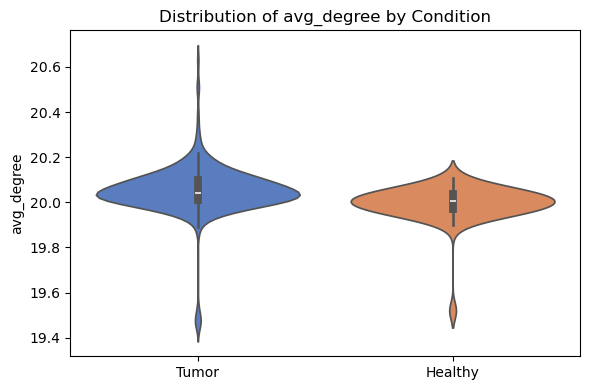

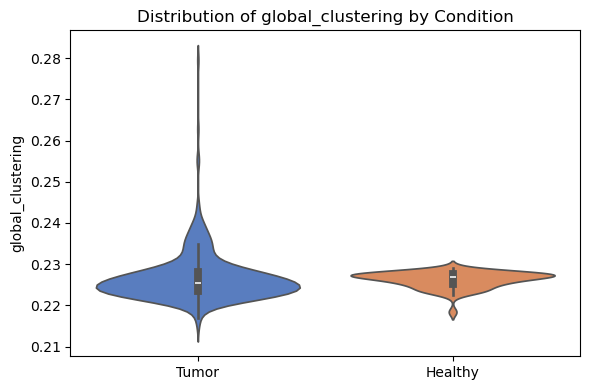

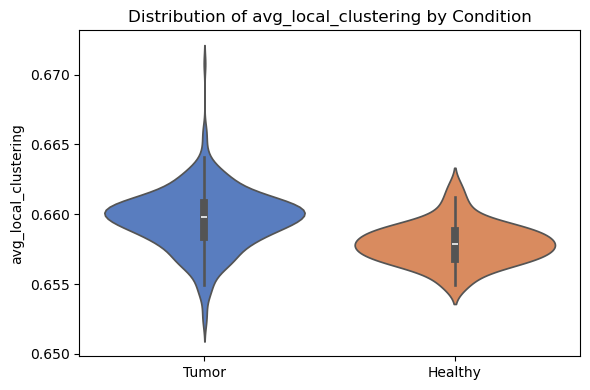

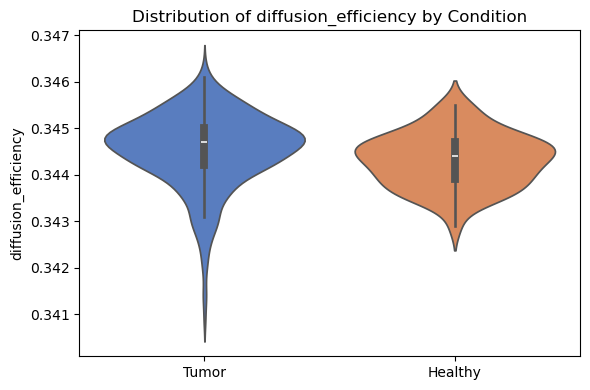

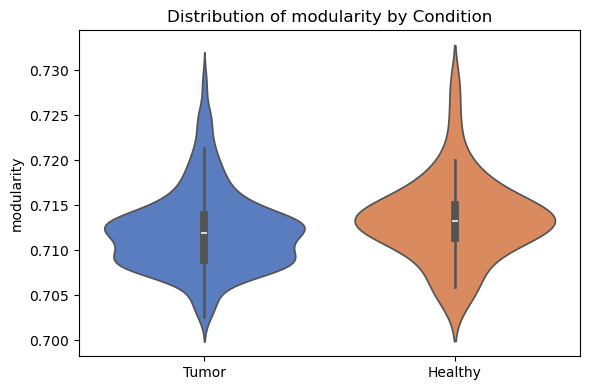

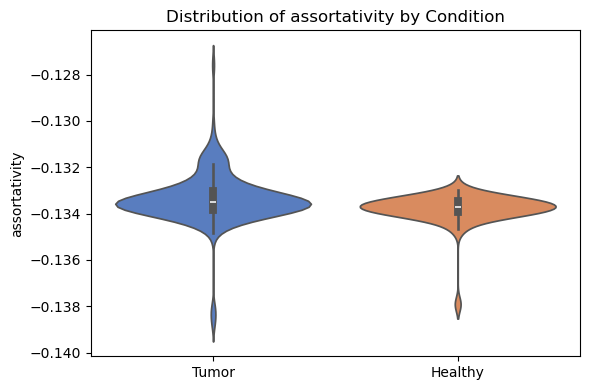

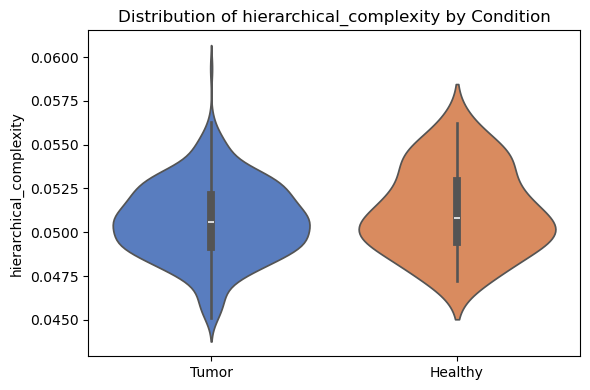

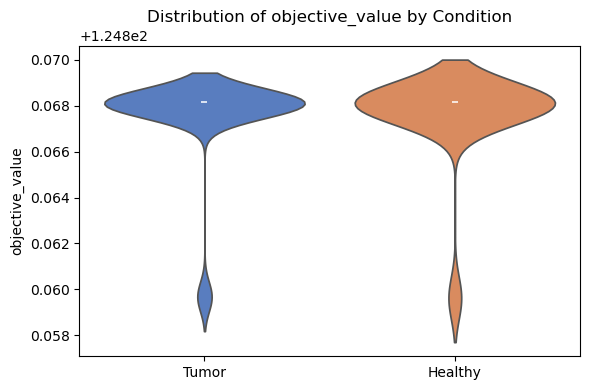

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

for metric in metrics:
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=full_df,
        x='condition_x',
        y=metric,
        hue='condition_x',
        palette='muted',
        legend=False 
    )
    plt.title(f'Distribution of {metric} by Condition')
    plt.xlabel('')
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

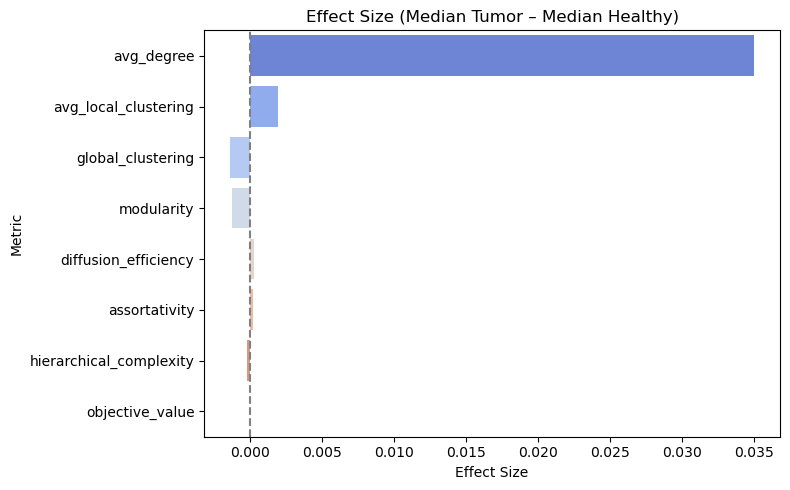

In [59]:
# Barplot sorted by absolute effect size
plt.figure(figsize=(8, 5))
sns.barplot(
    data=median_df_sorted.reset_index(),
    x='effect_size',
    y='index',
    hue='index',  
    dodge=False,
    palette='coolwarm',
    legend=False
)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Effect Size (Median Tumor – Median Healthy)')
plt.xlabel('Effect Size')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()

## Top Nodes 

In [69]:
import pickle
import networkx as nx
import pandas as pd
from collections import Counter

# Load the graphs from the pickle file
with open("graphs_by_sample.pkl", "rb") as f:
    loaded_graphs = pickle.load(f)

print(f"Total graphs loaded: {len(loaded_graphs)}")

Total graphs loaded: 423


In [79]:
# Count node appearances across all graphs
node_freq = Counter()
for G in loaded_graphs.values():
    node_freq.update(list(G.nodes))  

# Top 10 most frequent nodes
top_nodes = [node for node, count in node_freq.most_common(10)]
print("Top nodes:", top_nodes)

Top nodes: ['MAM01249c', 'MAM01796c', 'MAM02039c', 'MAM02552c', 'MAM02553c', 'MAM02554c', 'MAM02555c', 'MAM01252c', 'MAM01261c', 'MAM01334c']


## Node Level degree , only top 10 most frequent nodes

In [102]:
records = []

# Go through each graph (sample)
for sample_name, G in loaded_graphs.items():
    # Get the condition for that sample (Tumor or Healthy)
    match = full_df[full_df['sample'] == sample_name]
    if match.empty:
        continue  # skip unmatched samples
    
    condition = match['condition_x'].values[0]
    
    for node in top_nodes:
        if node in G:
            deg = G.degree[node]
            records.append({
                'sample': sample_name,
                'condition': condition,
                'node': node,
                'degree': deg
            })

# Convert to DataFrame
node_df = pd.DataFrame(records)
print("Shape:", node_df.shape)
node_df

Shape: (4230, 4)


,sample,condition,node,degree
0,TCGA_Tumor_A3A3,Tumor,MAM01249c,22
1,TCGA_Tumor_A3A3,Tumor,MAM01796c,10
2,TCGA_Tumor_A3A3,Tumor,MAM02039c,2694
3,TCGA_Tumor_A3A3,Tumor,MAM02552c,334
4,TCGA_Tumor_A3A3,Tumor,MAM02553c,316
...,...,...,...,...
4225,TCGA_Tumor_A9CD,Tumor,MAM02554c,740
4226,TCGA_Tumor_A9CD,Tumor,MAM02555c,739
4227,TCGA_Tumor_A9CD,Tumor,MAM01252c,69
4228,TCGA_Tumor_A9CD,Tumor,MAM01261c,124


In [104]:
#Getting matabolites names

meta_df = pd.read_csv("/Users/valentinreateguirangel/Downloads/Human-GEM-1.19.0/model/metabolites.tsv", sep="\t")
meta_df = meta_df.rename(columns={'mets': 'node', 'metBiGGID': 'metabolite_name'})

# Preview 
node_df = node_df.merge(meta_df[['node', 'metabolite_name']], on='node', how='left')

In [106]:
node_df

,sample,condition,node,degree,metabolite_name
0,TCGA_Tumor_A3A3,Tumor,MAM01249c,22,acald
1,TCGA_Tumor_A3A3,Tumor,MAM01796c,10,etoh
2,TCGA_Tumor_A3A3,Tumor,MAM02039c,2694,h
3,TCGA_Tumor_A3A3,Tumor,MAM02552c,334,nad
4,TCGA_Tumor_A3A3,Tumor,MAM02553c,316,nadh
...,...,...,...,...,...
4225,TCGA_Tumor_A9CD,Tumor,MAM02554c,740,nadp
4226,TCGA_Tumor_A9CD,Tumor,MAM02555c,739,nadph
4227,TCGA_Tumor_A9CD,Tumor,MAM01252c,69,ac
4228,TCGA_Tumor_A9CD,Tumor,MAM01261c,124,accoa


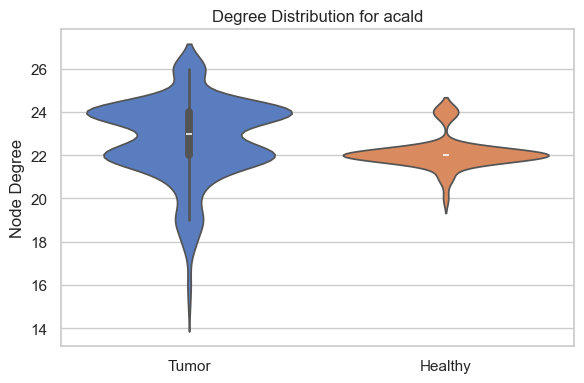

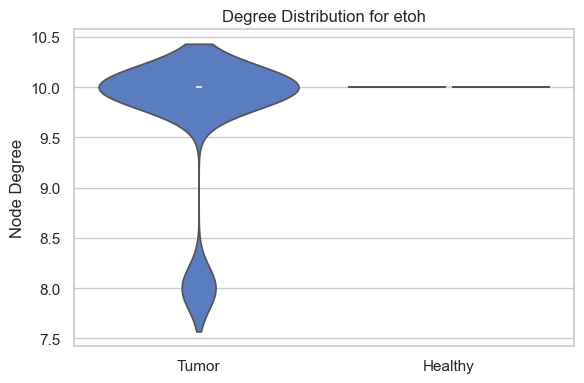

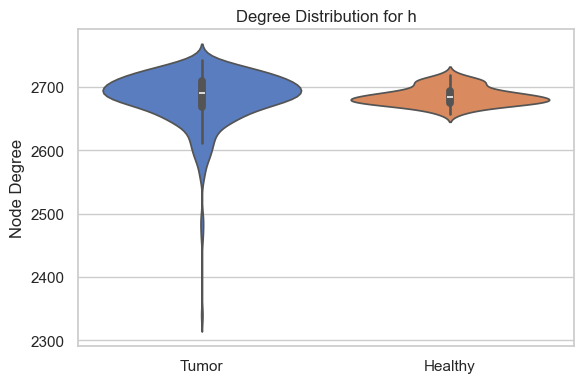

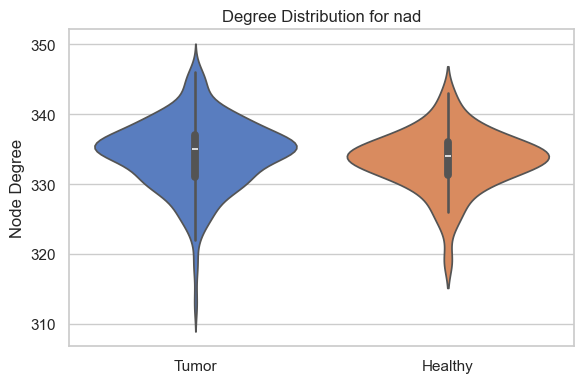

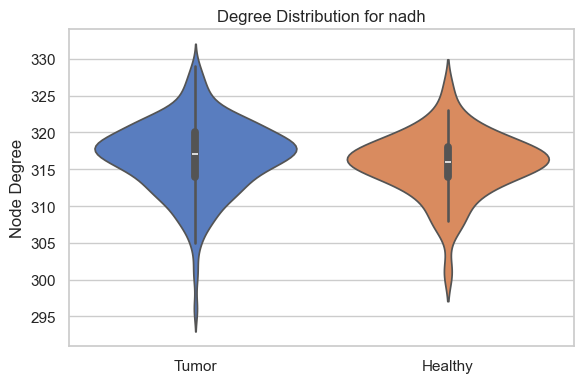

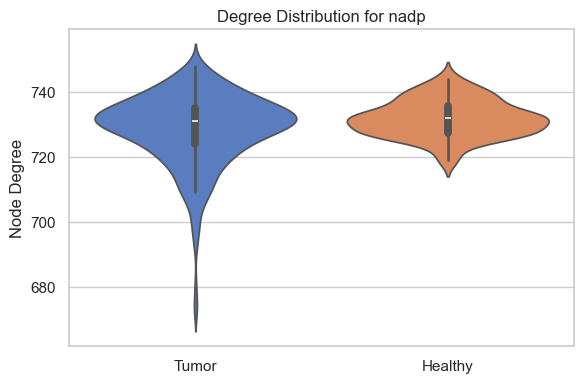

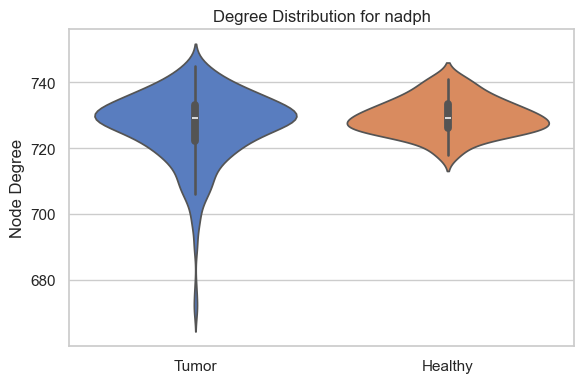

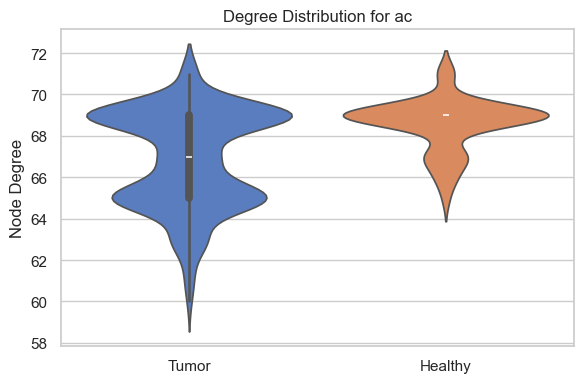

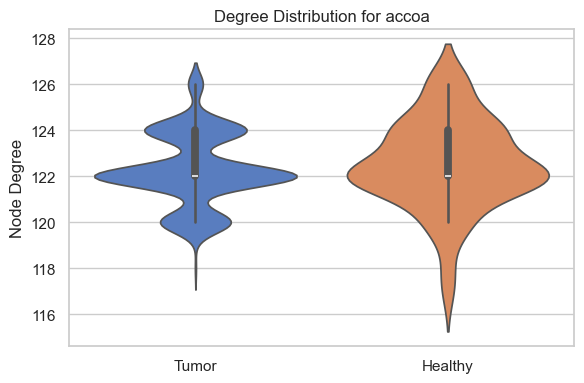

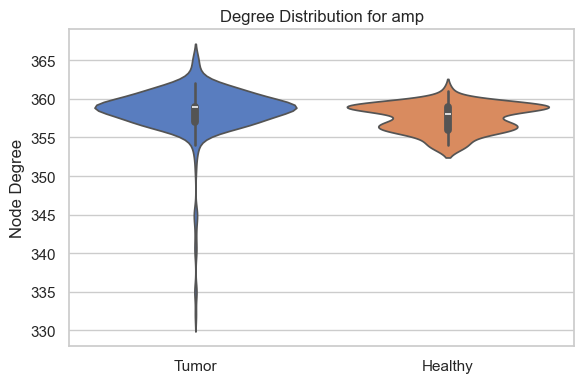

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for metabolite in node_df['metabolite_name'].unique():
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=node_df[node_df['metabolite_name'] == metabolite],
        x='condition',
        y='degree',
        hue='condition',           
        palette='muted',
        legend=False               
    )
    plt.title(f'Degree Distribution for {metabolite}')
    plt.ylabel('Node Degree')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

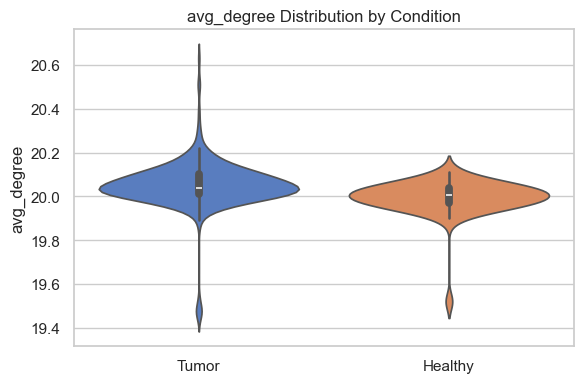

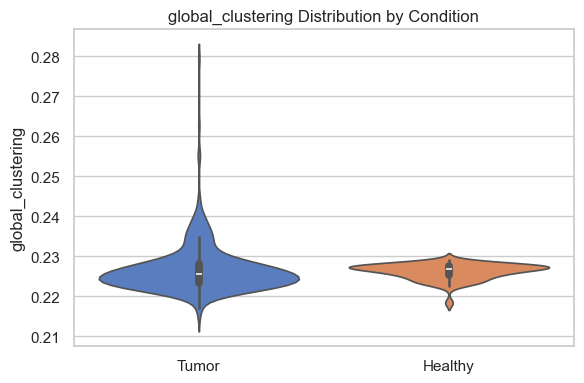

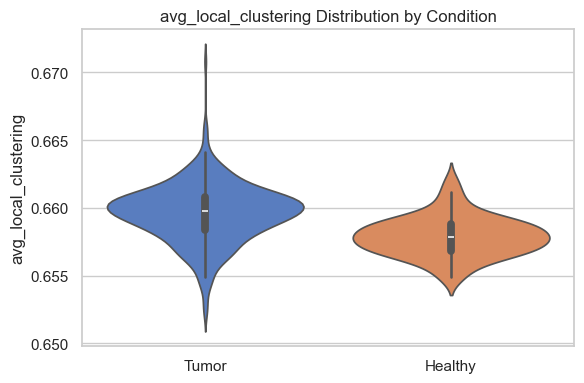

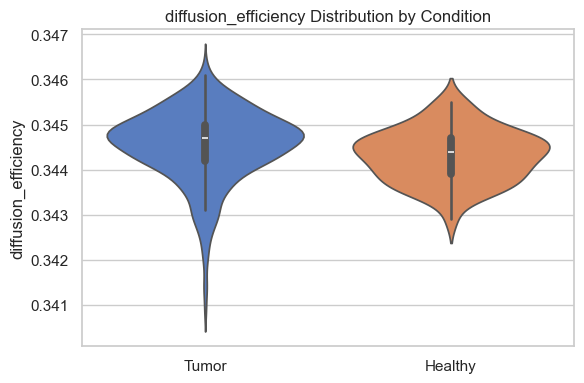

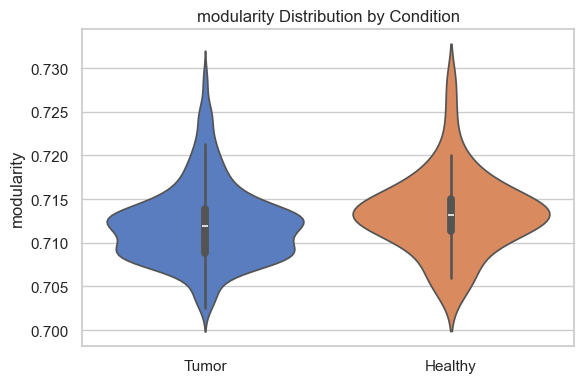

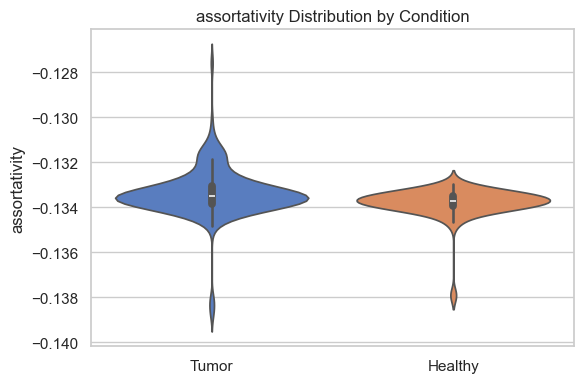

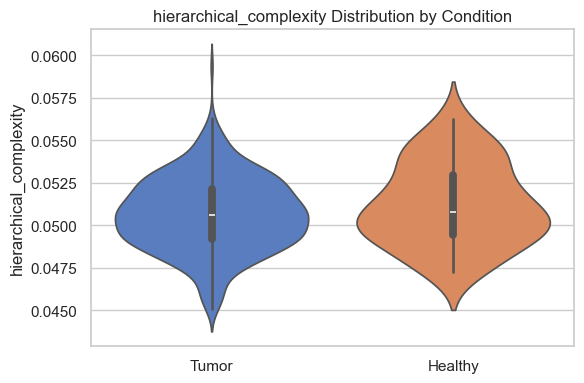

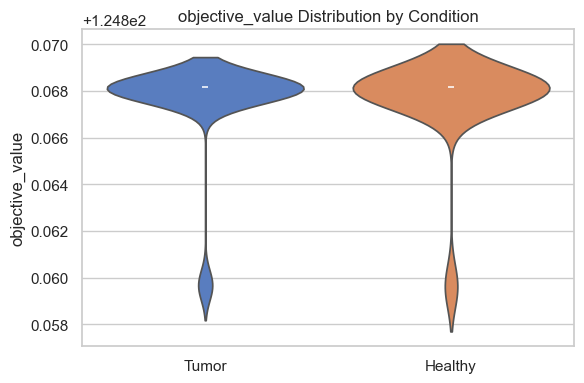

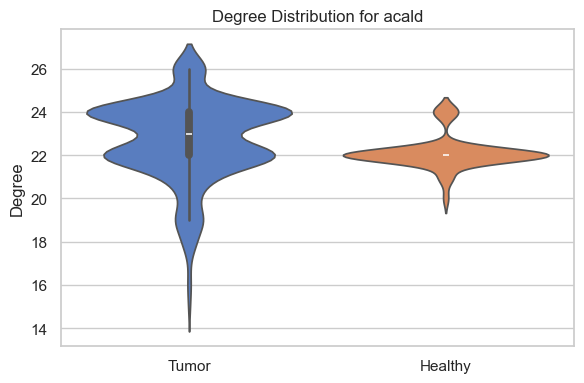

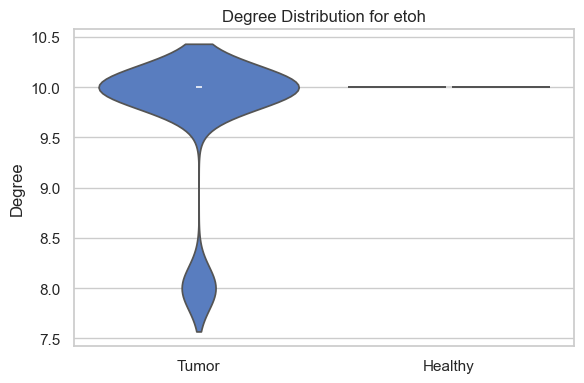

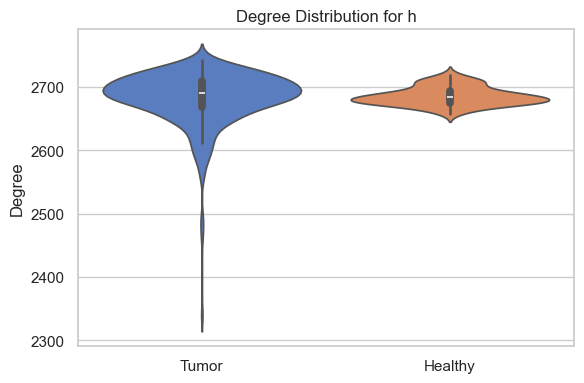

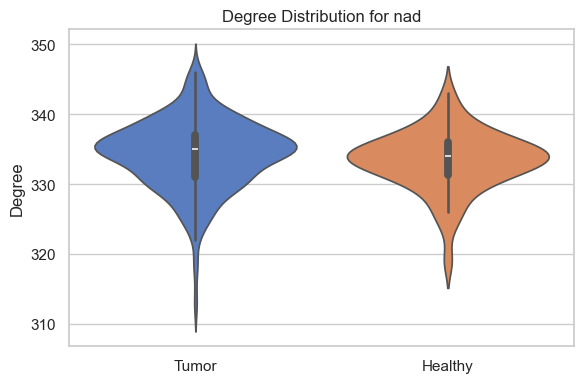

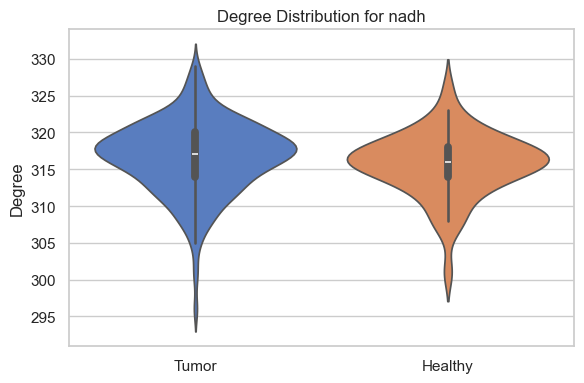

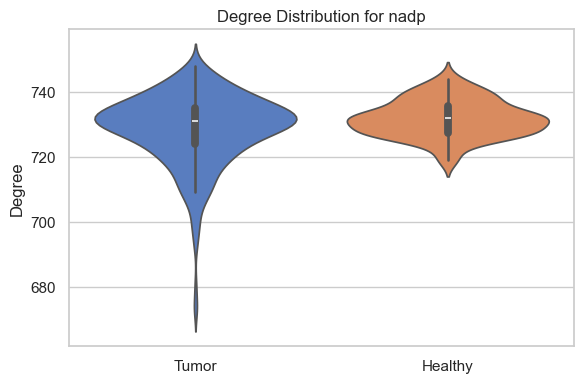

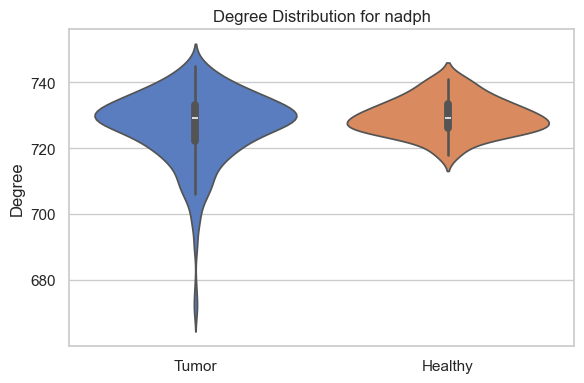

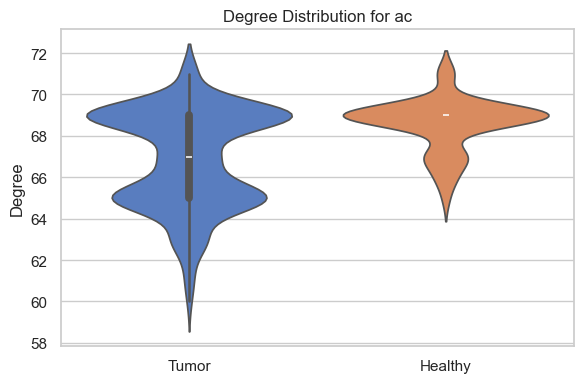

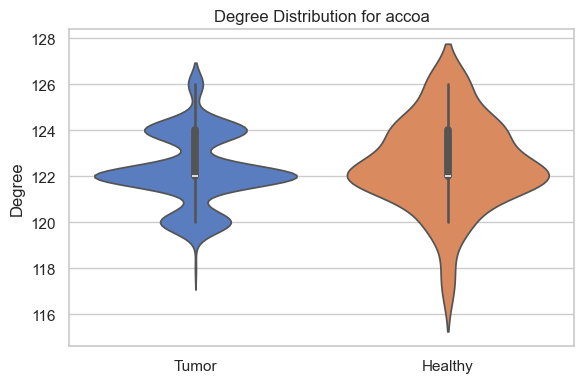

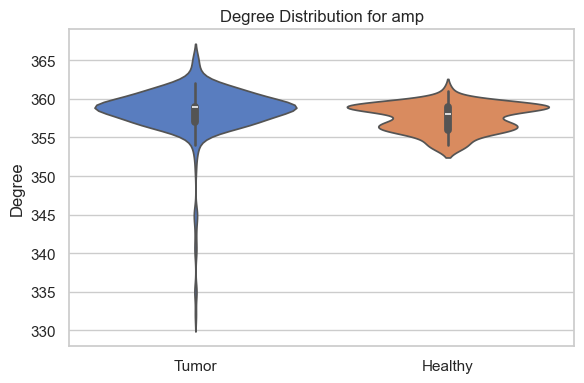


 Global Network Metrics Summary 
                     metric  median_tumor  median_healthy   effect_size  \
2     avg_local_clustering      0.659800        0.657850  1.950000e-03   
0               avg_degree     20.040000       20.005000  3.500000e-02   
5            assortativity     -0.133477       -0.133704  2.271252e-04   
3     diffusion_efficiency      0.344700        0.344400  3.000000e-04   
4               modularity      0.711919        0.713186 -1.267657e-03   
1        global_clustering      0.225500        0.226850 -1.350000e-03   
6  hierarchical_complexity      0.050613        0.050790 -1.775617e-04   
7          objective_value    124.868148      124.868148  2.842171e-14   

        p_value  
2  6.180001e-10  
0  1.283101e-07  
5  7.935804e-04  
3  3.144370e-03  
4  1.665857e-02  
1  8.934138e-02  
6  2.003557e-01  
7  7.008725e-01  

 Top Metabolite Node-Level Summary 
   metabolite  median_tumor  median_healthy  effect_size       p_value
7         ac          67.0  

In [120]:
import pandas as pd
import pickle
import networkx as nx
from collections import Counter
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
fba_df = pd.read_csv("fba_results.csv")
graph_df = pd.read_csv("graph_data_with_complexity.csv")
full_df = pd.merge(graph_df, fba_df, on='sample').drop(columns=['status', 'condition_y'])

# --- Step 2: Global Metrics Comparison (Tumor vs Healthy) ---
metrics = ['avg_degree', 'global_clustering', 'avg_local_clustering',
           'diffusion_efficiency', 'modularity', 'assortativity',
           'hierarchical_complexity', 'objective_value']

tumor_df = full_df[full_df['condition_x'] == 'Tumor']
healthy_df = full_df[full_df['condition_x'] == 'Healthy']

# Calculate medians and p-values
global_summary = []
for metric in metrics:
    tumor_vals = tumor_df[metric]
    healthy_vals = healthy_df[metric]

    median_tumor = tumor_vals.median()
    median_healthy = healthy_vals.median()
    effect_size = median_tumor - median_healthy
    _, p_value = mannwhitneyu(tumor_vals, healthy_vals, alternative='two-sided')

    global_summary.append({
        'metric': metric,
        'median_tumor': median_tumor,
        'median_healthy': median_healthy,
        'effect_size': effect_size,
        'p_value': p_value
    })

global_summary_df = pd.DataFrame(global_summary).sort_values(by='p_value')

# --- Step 3: Top Metabolite Node-Level Analysis ---
# Load graphs
with open("graphs_by_sample.pkl", "rb") as f:
    loaded_graphs = pickle.load(f)

# Find top 10 frequent nodes
node_freq = Counter()
for G in loaded_graphs.values():
    node_freq.update(list(G.nodes))
top_nodes = [n for n, _ in node_freq.most_common(10)]

# Extract node-level degrees
node_records = []
for sample_name, G in loaded_graphs.items():
    condition = full_df.loc[full_df['sample'] == sample_name, 'condition_x'].values[0]
    for node in top_nodes:
        if node in G:
            degree = G.degree[node]
            node_records.append({
                'sample': sample_name,
                'condition': condition,
                'node': node,
                'degree': degree
            })

node_df = pd.DataFrame(node_records)

# Map metabolite names
meta_df = pd.read_csv("/Users/valentinreateguirangel/Downloads/Human-GEM-1.19.0/model/metabolites.tsv", sep="\t")
meta_df.rename(columns={'mets': 'node', 'metBiGGID': 'metabolite_name'}, inplace=True)
node_df = node_df.merge(meta_df[['node', 'metabolite_name']], on='node', how='left')

# Metabolite-level summary statistics
node_summary = []
for met in node_df['metabolite_name'].unique():
    df = node_df[node_df['metabolite_name'] == met]
    tumor_deg = df[df['condition'] == 'Tumor']['degree']
    healthy_deg = df[df['condition'] == 'Healthy']['degree']
    
    median_tumor = tumor_deg.median()
    median_healthy = healthy_deg.median()
    effect_size = median_tumor - median_healthy
    _, p_val = mannwhitneyu(tumor_deg, healthy_deg, alternative='two-sided')

    node_summary.append({
        'metabolite': met,
        'median_tumor': median_tumor,
        'median_healthy': median_healthy,
        'effect_size': effect_size,
        'p_value': p_val
    })

node_summary_df = pd.DataFrame(node_summary).sort_values(by='p_value')

# --- Step 4: Plot Global Metrics (Violinplots) ---
sns.set(style="whitegrid")
for metric in metrics:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data=full_df, x='condition_x', y=metric, hue='condition_x', palette='muted', legend=False)
    plt.title(f'{metric} Distribution by Condition')
    plt.xlabel('')
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# --- Step 5: Plot Node-Level Metabolite Degrees ---
for met in node_df['metabolite_name'].unique():
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=node_df[node_df['metabolite_name'] == met],
        x='condition', y='degree', hue='condition',
        palette='muted', legend=False
    )
    plt.title(f'Degree Distribution for {met}')
    plt.xlabel('')
    plt.ylabel('Degree')
    plt.tight_layout()
    plt.show()

# --- Step 6: Display Summary Tables ---
print("\n Global Network Metrics Summary \n", global_summary_df)
print("\n Top Metabolite Node-Level Summary \n", node_summary_df)